# Car Price Predictive Analysis

## Project Overview

This project analyses car prices and vehicle characteristics to identify the factors that influence vehicle pricing.

The analysis will use data analysis, visualisation, hypothesis testing and machine learning to generate insights that can support vehicle pricing and product-positioning decisions.

## Project Objectives

This project aims to:

- Analyse the factors associated with car prices.
- Explore relationships between vehicle characteristics and price.
- Apply exploratory data analysis and visualisation to identify patterns and trends.
- Use statistical analysis and hypothesis testing to investigate relationships in the dataset.
- Develop and evaluate a machine learning regression model to predict car prices.
- Communicate key findings through visualisations and an interactive dashboard.
- Provide evidence-based insights to support vehicle pricing and product-positioning decisions.


In [1]:
import sys

print(sys.executable)
print(sys.version)

d:\car-price-predictive-analysis\.venv\Scripts\python.exe
3.12.8 (tags/v3.12.8:2dc476b, Dec  3 2024, 19:30:04) [MSC v.1942 64 bit (AMD64)]


---

## Change Working Directory

The notebook is stored inside the `jupyter_notebooks` folder, while the project files are stored in the parent project folder.

The working directory is changed to the project folder so that the dataset and other project files can be accessed using relative file paths.

In [2]:
import os
current_dir = os.getcwd()
current_dir

'd:\\car-price-predictive-analysis\\jupyter_notebooks'

### Set the Project Folder as the Working Directory

The notebook is stored in the `jupyter_notebooks` folder.  
The project dataset and other files are stored in the parent project folder.

The working directory is changed to the parent folder so that project files can be accessed using relative paths.

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


### Confirm the Working Directory

The current working directory is checked to confirm that the notebook is now working from the main project folder.

In [4]:
current_dir = os.getcwd()
current_dir

'd:\\car-price-predictive-analysis'

## Import Libraries

This section imports the Python libraries required for data manipulation, numerical analysis and data visualisation.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Load the Dataset

This section loads the car-price dataset into a pandas DataFrame, ready for initial inspection and subsequent data analysis.

In [6]:
# Load the car price dataset

df = pd.read_csv('inputs/CarPrice_Assignment.csv')

df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## Initial Dataset Inspection

This section examines the dataset's dimensions and column data types to understand its structure before carrying out data quality checks and exploratory data analysis.


In [7]:
# Check the dataset dimensions and column data types

print("Dataset shape:", df.shape)

print("\nColumn names and data types:")
df.info()

Dataset shape: (205, 26)

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    ob

---

> **Key Findings**
>
> - The dataset contains **205 rows and 26 columns**.
> - All 26 columns report 205 non-null entries, so the initial inspection shows no missing values.
> - The columns have three data types: `float64` (8 columns), `int64` (8 columns), and `object` (10 columns).
> - The `price` column is numeric and will be the target variable for the regression model.
>
> **Note:** Duplicate records and other potential data-quality issues have not yet been assessed.

## Missing Value Assessment

This check identifies the number of missing values in each column to determine whether any missing-data treatment is required before further analysis.

In [8]:
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

---

> **Key Findings**
>
> - All 26 columns contain **zero missing values**.
> - No missing-value imputation or removal is required at this stage.
> - Further data-quality checks are still needed to identify duplicate records and assess potential outliers.

## Duplicate Record Assessment

This check identifies exact duplicate rows in the dataset to determine whether duplicate records may affect the reliability of the analysis.

In [9]:
df.duplicated().sum()

0

---

> **Key Findings — Duplicate Records**
>
> - The dataset contains **0 exact duplicate rows**.
> - No duplicate-row removal is required based on this check.
> - This check does not identify inconsistencies or repeated values within individual columns.
>
> **Note:** All 205 records are retained at this stage. Further data-quality checks are needed to assess other potential issues.

## Outlier Detection Using the IQR Method

The Interquartile Range (IQR) method is used to identify potential outliers in numerical columns. It calculates the first quartile (Q1), third quartile (Q3), and IQR (Q3 − Q1). Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are flagged for further investigation.

In [10]:
numeric_cols = df.select_dtypes(include='number').columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
            (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()

outliers

car_ID               0
symboling            0
wheelbase            3
carlength            1
carwidth             8
carheight            0
curbweight           0
enginesize          10
boreratio            0
stroke              20
compressionratio    28
horsepower           6
peakrpm              2
citympg              2
highwaympg           3
price               15
dtype: int64

---

> **Key Findings — Outlier Detection**
>
> - The IQR method is used to identify potential outliers in numerical columns.
> - Values outside the IQR boundaries are flagged for further investigation.
> - A flagged value is not necessarily an error; it may represent a genuine characteristic of a vehicle.
>
> **Note:** Outlier detection results should be reviewed before deciding whether to retain, transform, or remove any values. Identifier columns, such as `car_ID`, should not be treated as meaningful numerical measurements.

## Data Cleaning and Feature Engineering

### 1.1 Manufacturer Name Standardisation

This step examines the manufacturer names extracted from the car name column and counts their occurrences. The results will help identify spelling inconsistencies that need to be standardised before further analysis.

In [11]:
# Extract raw brand names from CarName
raw_brands = df['CarName'].apply(lambda x: x.split(' ')[0].lower())

# Display sorted unique raw brand names and their frequencies
raw_brand_counts = raw_brands.value_counts().sort_index()
print(f"Total Unique Raw Brands Found: {len(raw_brand_counts)}\n")
print(raw_brand_counts)

Total Unique Raw Brands Found: 27

CarName
alfa-romero     3
audi            7
bmw             8
buick           8
chevrolet       3
dodge           9
honda          13
isuzu           4
jaguar          3
maxda           2
mazda          15
mercury         1
mitsubishi     13
nissan         18
peugeot        11
plymouth        7
porcshce        1
porsche         4
renault         2
saab            6
subaru         12
toyota         31
toyouta         1
vokswagen       1
volkswagen      9
volvo          11
vw              2
Name: count, dtype: int64


---

> **Key Findings — Raw Manufacturer Name Inspection**
>
> - **Unique Extracted Brands:** Initial extraction identifies **27 unique raw manufacturer tokens** across the dataset.
> - **Identified Spelling Inconsistencies & Typos:**
>   - `alfa-romero` instead of `alfa-romeo`
>   - `maxda` instead of `mazda`[cite: 2]
>   - `porcshz` instead of `porsche`
>   - `toyouta` instead of `toyota`
>   - `vokswagen` and `vw` instead of `volkswagen`[cite: 2]
>
> **Note:** These manufacturer name errors must be standardized to prevent duplicate brand entries during analysis and feature engineering[cite: 2].

### 1.3 Verify Standardised Manufacturer Names

This step checks the frequency of each standardised manufacturer name after applying the spelling corrections. Reviewing the counts helps confirm that known spelling variations have been consolidated and that the dataset is ready for further analysis.

In [12]:
# Define manufacturer spelling corrections and aliases
brand_corrections = {
    "alfa-romero": "alfa-romeo",
    "maxda": "mazda",
    "porcshz": "porsche",
    "porcshce": "porsche",
    "toyouta": "toyota",
    "vokswagen": "volkswagen",
    "vw": "volkswagen"
}

# Apply spelling corrections to the extracted manufacturer names
df["brand"] = df["brand"].replace(brand_corrections)

# Verify the corrected manufacturer names
print("Unique cleaned brands:")
print(sorted(df["brand"].unique()))

KeyError: 'brand'

---

> **Key Findings — Manufacturer Name Validation**
>
> - The manufacturer labels have been standardised using the defined spelling-correction dictionary.
> - The frequency counts show the number of records associated with each standardised manufacturer.
> - Reviewing these counts helps identify whether any known spelling variations remain.
>
> **Note:** The original `CarName` column has been preserved. The frequency output should be reviewed to confirm that the corrections have been applied successfully.

### 1.4 Extract Car Model Names

The `CarName` column contains both the manufacturer name and the car model. This step extracts the model name by removing the first word, which represents the manufacturer, and converting the remaining text to lowercase.

The extracted model names are stored in a new `car_model` column, while the original `CarName` column is preserved. This separation supports further exploratory data analysis and comparisons between vehicle models.

In [ ]:
# Extract the car model name from CarName
df["car_model"] = (
    df["CarName"]
    .str.split()
    .str[1:]
    .str.join(" ")
    .str.lower()
)

# Display the original name, brand, and extracted model
display(df[["CarName", "brand", "car_model"]].head(10))

,CarName,brand,car_model
0,alfa-romero giulia,alfa-romeo,giulia
1,alfa-romero stelvio,alfa-romeo,stelvio
2,alfa-romero Quadrifoglio,alfa-romeo,quadrifoglio
3,audi 100 ls,audi,100 ls
4,audi 100ls,audi,100ls
5,audi fox,audi,fox
6,audi 100ls,audi,100ls
7,audi 5000,audi,5000
8,audi 4000,audi,4000
9,audi 5000s (diesel),audi,5000s (diesel)


---

> **Key Findings — Car Model Extraction**
>
> - The `car_model` column has been created by extracting the words following the manufacturer name in `CarName`.
> - The extracted model names have been converted to lowercase for consistency.
> - The sample output confirms that manufacturer names and model names are stored in separate columns.
> - The original `CarName` column has been preserved for reference and validation.
>
> **Note:** This step separates the existing information; it does not create new vehicle specifications or guarantee that every model name is unique.

### 1.5 Standardise Car Model Names

Some car model labels may contain minor inconsistencies in spacing or naming. This step standardises selected model names using a dictionary of known corrections to improve consistency during exploratory data analysis.

In [ ]:
# Define known car model name corrections
model_corrections = {
    "100 ls": "100ls",
    "5000s (diesel)": "5000s"
}

# Apply the corrections to the car_model column
df["car_model"] = df["car_model"].replace(model_corrections)

# Verify the corrected model names
print("Updated car model examples:")
display(df[["CarName", "brand", "car_model"]].head(10))

Updated car model examples:


,CarName,brand,car_model
0,alfa-romero giulia,alfa-romeo,giulia
1,alfa-romero stelvio,alfa-romeo,stelvio
2,alfa-romero Quadrifoglio,alfa-romeo,quadrifoglio
3,audi 100 ls,audi,100ls
4,audi 100ls,audi,100ls
5,audi fox,audi,fox
6,audi 100ls,audi,100ls
7,audi 5000,audi,5000
8,audi 4000,audi,4000
9,audi 5000s (diesel),audi,5000s


---

> **Key Findings — Car Model Standardisation**
>
> - Selected model labels have been standardised using a predefined correction dictionary.
> - The corrections address differences in spacing and remove the diesel label from the selected model name.
> - The original `CarName` column remains unchanged, allowing the cleaned values to be checked against the source data.
>
> **Note:** These corrections are limited to the explicitly listed labels. Other model variations should be investigated before applying additional changes.

### 1.6 Create Derived Business Features

Feature engineering involves creating new variables from existing data to support the business objectives of this project.

This step introduces three derived features:

- `price_per_hp`: vehicle price divided by horsepower, representing price relative to engine power.
- `power_to_weight`: horsepower divided by curb weight, representing engine power relative to vehicle weight.
- `avg_mpg`: the average of city and highway miles per gallon, providing a simple measure of fuel economy.

These features will be examined during exploratory data analysis to investigate their relationships with car prices and other vehicle characteristics.

In [ ]:
# 1. Calculate price per horsepower
df["price_per_hp"] = df["price"] / df["horsepower"]

# 2. Calculate the horsepower-to-weight ratio
df["power_to_weight"] = df["horsepower"] / df["curbweight"]

# 3. Calculate average fuel economy from city and highway MPG
df["avg_mpg"] = (df["citympg"] + df["highwaympg"]) / 2

In [ ]:
# Display the original variables and the newly created features
display(
    df[
        [
            "price",
            "horsepower",
            "curbweight",
            "citympg",
            "highwaympg",
            "price_per_hp",
            "power_to_weight",
            "avg_mpg"
        ]
    ].head(10)
)

,price,horsepower,curbweight,citympg,highwaympg,price_per_hp,power_to_weight,avg_mpg
0,13495.000,111,2548,21,27,121.576577,0.043564,24.0
1,16500.000,111,2548,21,27,148.648649,0.043564,24.0
2,16500.000,154,2823,19,26,107.142857,0.054552,22.5
3,13950.000,102,2337,24,30,136.764706,0.043646,27.0
4,17450.000,115,2824,18,22,151.739130,0.040722,20.0
5,15250.000,110,2507,19,25,138.636364,0.043877,22.0
6,17710.000,110,2844,19,25,161.000000,0.038678,22.0
7,18920.000,110,2954,19,25,172.000000,0.037238,22.0
8,23875.000,140,3086,17,20,170.535714,0.045366,18.5
9,17859.167,160,3053,16,22,111.619794,0.052407,19.0


---

> **Key Findings — Feature Engineering**
>
> - Three derived features have been created: `price_per_hp`, `power_to_weight`, and `avg_mpg`.
> - `price_per_hp` represents vehicle price relative to horsepower.
> - `power_to_weight` represents horsepower relative to curb weight.
> - `avg_mpg` is calculated as the arithmetic mean of city and highway miles per gallon.
>
> **Note:** These features provide additional variables for exploratory data analysis. Their relationships with car prices will be investigated in subsequent sections. The calculated values should be checked for unexpected or invalid results before modelling.

### 1.7 Validate Derived Features

This step checks the newly created features to confirm that the calculations have produced valid numerical values. Although the original dataset contains no missing values, validation is necessary to ensure that feature engineering has not introduced missing or infinite values through invalid mathematical operations.

In [ ]:
# Check missing values in the derived features
derived_features = [
    "price_per_hp",
    "power_to_weight",
    "avg_mpg"
]

print("Missing values:")
print(df[derived_features].isnull().sum())

print("\nInfinite values:")
print(
    df[derived_features]
    .isin([float("inf"), float("-inf")])
    .sum()
)

Missing values:
price_per_hp       0
power_to_weight    0
avg_mpg            0
dtype: int64

Infinite values:
price_per_hp       0
power_to_weight    0
avg_mpg            0
dtype: int64


---

> **Key Findings — Derived Feature Validation**
>
> - `price_per_hp` contains 0 missing values and 0 infinite values.
> - `power_to_weight` contains 0 missing values and 0 infinite values.
> - `avg_mpg` contains 0 missing values and 0 infinite values.
> - The validation confirms that the three derived features contain no missing or infinite values.
>
> **Conclusion:** No additional missing-value treatment is required for these derived features at this stage.

### 1.8 Inspect the Transformed Dataset Structure

After completing the initial data cleaning and feature engineering steps, the dataset is inspected to assess its updated structure.

This check examines the number of rows and columns, reviews the column names, and displays a sample of records. It helps confirm that the original observations have been retained and that the newly created features are present before the next stage of the ETL process.

In [ ]:
# Check the dataset dimensions after feature engineering
print("Dataset shape:", df.shape)

# Display the column names
print("\nDataset columns:")
print(df.columns.tolist())

# Inspect the first five rows
display(df.head())

Dataset shape: (205, 33)

Dataset columns:
['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price', 'CarName_Clean', 'Brand', 'brand', 'car_model', 'price_per_hp', 'power_to_weight', 'avg_mpg']


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,citympg,highwaympg,price,CarName_Clean,Brand,brand,car_model,price_per_hp,power_to_weight,avg_mpg
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,21,27,13495.0,alfa-romero giulia,alfa-romero,alfa-romeo,giulia,121.576577,0.043564,24.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,21,27,16500.0,alfa-romero stelvio,alfa-romero,alfa-romeo,stelvio,148.648649,0.043564,24.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,19,26,16500.0,alfa-romero Quadrifoglio,alfa-romero,alfa-romeo,quadrifoglio,107.142857,0.054552,22.5
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,24,30,13950.0,audi 100 ls,audi,audi,100ls,136.764706,0.043646,27.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,18,22,17450.0,audi 100ls,audi,audi,100ls,151.739130,0.040722,20.0


---

> **Key Findings — Transformed Dataset Structure**
>
> - The dataset contains **205 rows and 33 columns** after the transformations completed so far.
> - All 205 original records have been retained.
> - The dataset contains two manufacturer columns, `Brand` and `brand`, which represent the same information and need to be consolidated into one column.
> - Other new features include `car_model`, `price_per_hp`, `power_to_weight`, and `avg_mpg`.
> - The original vehicle attributes, including `CarName` and `price`, have been retained.
>
> **Next step:** Remove the duplicate manufacturer column, verify the final dataset structure, and prepare the transformed dataset for export.

#### Remove Duplicate Manufacturer Column

The `Brand` and `brand` columns contain the same type of information. This step removes the redundant `Brand` column and retains the lowercase `brand` column for consistency.

In [ ]:
# Remove the duplicate Brand column, keeping the lowercase brand column
if "Brand" in df.columns:
    df = df.drop(columns=["Brand"])

# Verify the remaining brand-related columns
print("Brand-related columns:")
print([col for col in df.columns if "brand" in col.lower()])

# Check the updated dataset dimensions
print("\nUpdated dataset shape:", df.shape)

Brand-related columns:
['brand']

Updated dataset shape: (205, 32)


### 1.9 Verify the Final Transformed Dataset

After cleaning the manufacturer names, extracting car models, creating derived features, and removing the duplicate manufacturer column, the dataset structure is checked again.

This verification confirms the final number of rows and columns, reviews the column names, and checks that the original `CarName` column and the new `brand` and `car_model` columns are retained. It also helps confirm that the dataset is organised correctly before exporting it as a separate cleaned CSV file.

In [ ]:
# Verify the dataset dimensions
print("Final dataset shape:", df.shape)

# Display all column names
print("\nFinal column names:")
print(df.columns.tolist())

# Confirm that the original and cleaned name columns are retained
print("\nName-related columns:")
print(df[["CarName", "brand", "car_model"]].head())

Final dataset shape: (205, 32)

Final column names:
['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price', 'CarName_Clean', 'brand', 'car_model', 'price_per_hp', 'power_to_weight', 'avg_mpg']

Name-related columns:
                    CarName       brand     car_model
0        alfa-romero giulia  alfa-romeo        giulia
1       alfa-romero stelvio  alfa-romeo       stelvio
2  alfa-romero Quadrifoglio  alfa-romeo  quadrifoglio
3               audi 100 ls        audi         100ls
4                audi 100ls        audi         100ls


---

> **Key Findings — Final Dataset Structure**
>
> - The transformed dataset contains **205 rows and 32 columns**.
> - All 205 original records have been retained.
> - The duplicate `Brand` column has been removed, leaving one standardised manufacturer column, `brand`.
> - The original `CarName` column and the extracted `car_model` column are retained.
> - The derived features `price_per_hp`, `power_to_weight`, and `avg_mpg` are included in the transformed dataset.
>
> **Next step:** Export the transformed dataset to a separate CSV file while preserving the original dataset.

## ETL: Load the Cleaned Dataset

### Export the Cleaned Dataset

In [ ]:
# Export the transformed dataset to the outputs folder
df.to_csv("outputs/car_prices_cleaned.csv", index=False)

# Confirm the export
print("Cleaned dataset exported successfully.")
print("Dataset shape:", df.shape)

Cleaned dataset exported successfully.
Dataset shape: (205, 32)


---

> **Key Findings — Cleaned Dataset Export**
>
> - The transformed dataset was successfully exported to `outputs/car_prices_cleaned.csv`.
> - The exported dataset contains **205 rows and 32 columns**.
> - The CSV file preserves the cleaned manufacturer names, extracted car models, and derived business features.
> - The original dataset remains unchanged.
>
> **Conclusion:** The transformed dataset is now available as a separate file for subsequent exploratory data analysis, statistical analysis, and machine learning.

### Descriptive Statistical Analysis

Descriptive statistics summarise the main characteristics of the dataset and help us understand typical values, variability, and the range of vehicle prices and specifications.

This analysis examines the mean, median, standard deviation, minimum, maximum, and quartiles of selected numerical variables. These measures help us understand the dataset before conducting hypothesis testing and building machine learning models.

The results will help identify important patterns in car prices and vehicle characteristics that deserve further investigation.

In [ ]:
# Select all numerical features, excluding car_ID and symboling
numerical_columns = df.select_dtypes(include="number").columns.drop(
    ["car_ID", "symboling"]
)

# Calculate descriptive statistics for the selected features
descriptive_stats = df[numerical_columns].describe().T

# Add variance and median
descriptive_stats["variance"] = df[numerical_columns].var()
descriptive_stats["median"] = df[numerical_columns].median()

# Display the results rounded to two decimal places
display(descriptive_stats.round(2))

,count,mean,std,min,25%,50%,75%,max,variance,median
wheelbase,205.0,98.76,6.02,86.60,94.50,97.00,102.40,120.90,36.26,97.00
carlength,205.0,174.05,12.34,141.10,166.30,173.20,183.10,208.10,152.21,173.20
carwidth,205.0,65.91,2.15,60.30,64.10,65.50,66.90,72.30,4.60,65.50
carheight,205.0,53.72,2.44,47.80,52.00,54.10,55.50,59.80,5.97,54.10
curbweight,205.0,2555.57,520.68,1488.00,2145.00,2414.00,2935.00,4066.00,271107.87,2414.00
enginesize,205.0,126.91,41.64,61.00,97.00,120.00,141.00,326.00,1734.11,120.00
boreratio,205.0,3.33,0.27,2.54,3.15,3.31,3.58,3.94,0.07,3.31
stroke,205.0,3.26,0.31,2.07,3.11,3.29,3.41,4.17,0.10,3.29
compressionratio,205.0,10.14,3.97,7.00,8.60,9.00,9.40,23.00,15.78,9.00
horsepower,205.0,104.12,39.54,48.00,70.00,95.00,116.00,288.00,1563.74,95.00


---

> **Key Findings — Descriptive Statistical Analysis**
>
> - The dataset contains **205 vehicles**, and all numerical features shown have 205 observations.
> - The mean car price is **13,276.71**, while the median is **10,295.00**. The difference suggests a right-skewed price distribution, consistent with the price distribution explored earlier.
> - Engine size has a mean of **126.91** and a median of **120.00**, while horsepower has a mean of **104.12** and a median of **95.00**.
> - Mean curb weight is **2,555.57**, compared with a median of **2,414.00**, indicating variation in vehicle weight.
> - Mean fuel economy is **25.22 mpg in city driving** and **30.75 mpg on highways**. The derived `avg_mpg` feature has a mean of **27.99 mpg**.
> - The range of prices, engine sizes, and horsepower values indicates substantial differences between vehicles in this dataset.
>
> **Conclusion:** Descriptive statistics establish a baseline understanding of vehicle prices and specifications. Further exploratory analysis and hypothesis testing are needed to investigate which characteristics are associated with price differences.

### Detailed Analysis of the Target Variable: Price

The target variable, `price`, represents the vehicle price that the predictive model will aim to estimate.

Measures of central tendency describe a typical price, while measures of dispersion describe how widely prices vary. The mean and standard deviation can be influenced by unusually expensive vehicles, whereas the median and interquartile range (IQR) are more robust to extreme values.

Skewness describes the asymmetry of the price distribution, while kurtosis helps characterise its tails and concentration. These measures support our understanding of the data and inform the choice and interpretation of subsequent statistical methods.

The distribution will be assessed using numerical statistics and the existing histogram and boxplot.

In [ ]:
# Calculate detailed descriptive statistics for car prices
price = df["price"]

price_stats = pd.Series({
    "Count": price.count(),
    "Mean": price.mean(),
    "Median": price.median(),
    "Mode": price.mode().tolist(),
    "Standard deviation": price.std(),
    "Variance": price.var(),
    "Minimum": price.min(),
    "First quartile (Q1)": price.quantile(0.25),
    "Third quartile (Q3)": price.quantile(0.75),
    "Maximum": price.max(),
    "Interquartile range (IQR)": (
        price.quantile(0.75) - price.quantile(0.25)
    ),
    "Skewness": price.skew(),
    "Kurtosis (excess)": price.kurt()
})

display(price_stats.to_frame(name="Value").round(2))

,Value
Count,205
Mean,13276.710571
Median,10295.0
Mode,"[5572.0, 6229.0, 6692.0, 7295.0, 7609.0, 7775...."
Standard deviation,7988.852332
Variance,63821761.578398
Minimum,5118.0
First quartile (Q1),7788.0
Third quartile (Q3),16503.0
Maximum,45400.0


---

> **Key Findings — Target Variable Analysis**
>
> - The dataset contains **205 vehicles**.
> - The mean price is **13,276.71**, compared with a median of **10,295**. The higher mean is consistent with a right-skewed distribution.
> - The interquartile range (IQR) is **8,715**, with the middle 50% of prices between **7,788 and 16,503**.
> - The standard deviation is approximately **7,988.85**, indicating substantial variability in vehicle prices.
> - Skewness is **1.78**, indicating a positively skewed distribution.
> - Excess kurtosis is **3.05**, indicating heavier tails and/or a more concentrated centre than a normal distribution.
>
> **Conclusion:** The price distribution is not symmetric and shows substantial variability. The median and IQR provide useful robust summaries alongside the mean and standard deviation. Statistical test selection should also consider the research question, sample sizes, independence and relevant test assumptions.

### Descriptive Statistics for Continuous Features

This section examines four continuous vehicle characteristics: `enginesize`, `horsepower`, `curbweight`, and `avg_mpg`.

For each feature, we will calculate measures of central tendency and spread, together with skewness and the interquartile range (IQR). These statistics help us understand the distribution and variability of each feature.

Potential outliers will be screened using the IQR rule. Values identified by this method will be investigated rather than automatically removed, because they may represent genuine differences between vehicles.

In [ ]:
# Select the four continuous vehicle features
continuous_features = [
    "enginesize",
    "horsepower",
    "curbweight",
    "avg_mpg"
]

# Calculate descriptive statistics
continuous_stats = df[continuous_features].describe().T

# Add median, interquartile range (IQR), and skewness
continuous_stats["median"] = df[continuous_features].median()

continuous_stats["IQR"] = (
    continuous_stats["75%"] - continuous_stats["25%"]
)

continuous_stats["skewness"] = df[continuous_features].skew()

# Arrange columns in a logical order
continuous_stats = continuous_stats[
    [
        "count", "mean", "std", "median", "IQR",
        "min", "25%", "50%", "75%", "max", "skewness"
    ]
]

# Display the summary table rounded to two decimal places
display(continuous_stats.round(2))

,count,mean,std,median,IQR,min,25%,50%,75%,max,skewness
enginesize,205.0,126.91,41.64,120.0,44.0,61.0,97.0,120.0,141.0,326.0,1.95
horsepower,205.0,104.12,39.54,95.0,46.0,48.0,70.0,95.0,116.0,288.0,1.41
curbweight,205.0,2555.57,520.68,2414.0,790.0,1488.0,2145.0,2414.0,2935.0,4066.0,0.68
avg_mpg,205.0,27.99,6.67,27.0,9.5,15.0,22.5,27.0,32.0,51.5,0.62


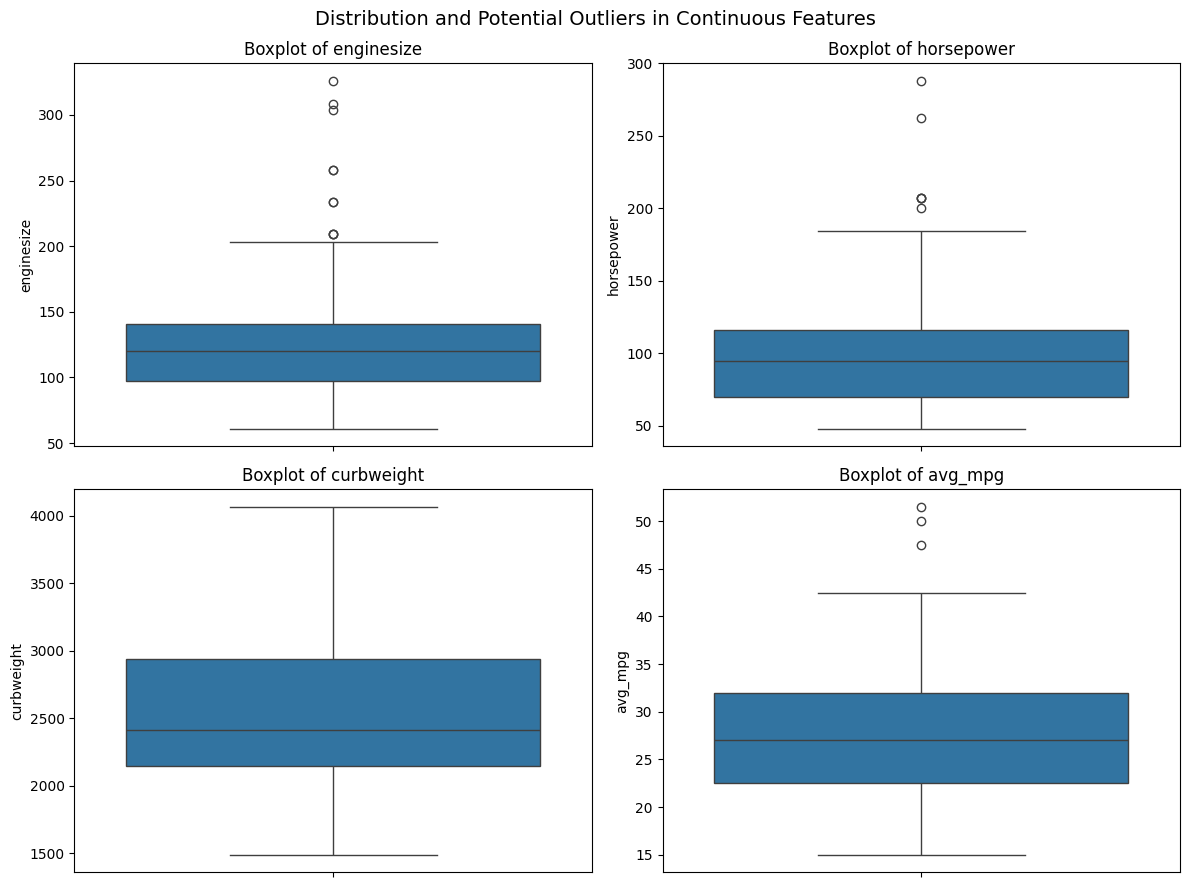

In [ ]:
# Create four boxplots in a 2 × 2 layout
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Define the features and their positions
plot_features = [
    ("enginesize", axes[0, 0]),
    ("horsepower", axes[0, 1]),
    ("curbweight", axes[1, 0]),
    ("avg_mpg", axes[1, 1])
]

# Draw each boxplot with the correct title and axis label
for feature, ax in plot_features:
    sns.boxplot(data=df, y=feature, ax=ax)
    ax.set_title(f"Boxplot of {feature}")
    ax.set_xlabel("")
    ax.set_ylabel(feature)

fig.suptitle(
    "Distribution and Potential Outliers in Continuous Features",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Outlier Identification Using the IQR Method

The interquartile range (IQR) method identifies potential outliers by examining values outside the expected range of the middle 50% of observations.

The IQR is calculated as the third quartile (Q3) minus the first quartile (Q1).

- **Lower bound:** Q1 − 1.5 × IQR
- **Upper bound:** Q3 + 1.5 × IQR

Values below the lower bound or above the upper bound are flagged as potential outliers. These thresholds identify unusual observations but do not prove that the values are errors.

In this project, the method will be applied to engine size, horsepower and average miles per gallon (`avg_mpg`). Potential outliers will be retained unless further investigation identifies a data-quality problem.

In [31]:
# Create a separate copy for outlier analysis
outlier_df = df.copy()

# Calculate average MPG in the copy only
outlier_df["avg_mpg"] = (
    outlier_df["citympg"] + outlier_df["highwaympg"]
) / 2

# Select features for the IQR outlier audit
outlier_features = ["enginesize", "horsepower", "avg_mpg"]

# Store the results
outlier_results = []

for feature in outlier_features:
    # Calculate the first and third quartiles
    q1 = outlier_df[feature].quantile(0.25)
    q3 = outlier_df[feature].quantile(0.75)

    # Calculate the interquartile range
    iqr = q3 - q1

    # Calculate the outlier thresholds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Identify observations outside the thresholds
    outlier_mask = (
        (outlier_df[feature] < lower_bound) |
        (outlier_df[feature] > upper_bound)
    )

    outlier_count = outlier_mask.sum()

    # Record the results
    outlier_results.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": (
            outlier_count / len(outlier_df) * 100
        )
    })

# Display the summary table
iqr_outlier_summary = pd.DataFrame(outlier_results)
display(iqr_outlier_summary.round(2))

# Confirm that the original DataFrame was not changed
print("Original df contains avg_mpg:", "avg_mpg" in df.columns)
print("Analysis copy contains avg_mpg:", "avg_mpg" in outlier_df.columns)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,enginesize,97.0,141.0,44.0,31.00,207.00,10,4.88
1,horsepower,70.0,116.0,46.0,1.00,185.00,6,2.93
2,avg_mpg,22.5,32.0,9.5,8.25,46.25,3,1.46


Original df contains avg_mpg: False
Analysis copy contains avg_mpg: True


---

> **Key Findings — IQR Outlier Analysis**
>
> - **Engine size:** 10 observations (4.88%) fall outside the IQR bounds of 31 to 207.
> - **Horsepower:** 6 observations (2.93%) fall outside the bounds of 1 to 185.
> - **Average MPG:** 3 observations (1.46%) fall outside the bounds of 8.25 to 46.25.
> - **Interpretation:** These observations are potential outliers, not necessarily data errors.
> - **Handling decision:** The observations will be retained unless further investigation identifies data-quality problems.
>
> **Conclusion:** The IQR method identified a small proportion of potential outliers. These observations will be retained for subsequent analysis unless evidence indicates that they are incorrect.

In [36]:
# Create a separate copy for the IQR analysis
outlier_df = df.copy()

# Calculate average MPG in the copy only
outlier_df["avg_mpg"] = (
    outlier_df["citympg"] + outlier_df["highwaympg"]
) / 2

# Select features for the outlier analysis
outlier_features = ["enginesize", "horsepower", "avg_mpg"]

outlier_results = []

for feature in outlier_features:

    # Calculate quartiles and IQR
    q1 = outlier_df[feature].quantile(0.25)
    q3 = outlier_df[feature].quantile(0.75)
    iqr = q3 - q1

    # Calculate IQR bounds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Count potential outliers
    outlier_mask = (
        (outlier_df[feature] < lower_bound) |
        (outlier_df[feature] > upper_bound)
    )

    outlier_count = outlier_mask.sum()

    # Store the results
    outlier_results.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": (
            outlier_count / len(outlier_df) * 100
        )
    })

# Display the summary table
iqr_outlier_summary = pd.DataFrame(outlier_results)
display(iqr_outlier_summary.round(2))

# Confirm the original DataFrame remains unchanged
print("avg_mpg in original df:", "avg_mpg" in df.columns)
print("avg_mpg in outlier_df:", "avg_mpg" in outlier_df.columns)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,enginesize,97.0,141.0,44.0,31.00,207.00,10,4.88
1,horsepower,70.0,116.0,46.0,1.00,185.00,6,2.93
2,avg_mpg,22.5,32.0,9.5,8.25,46.25,3,1.46


avg_mpg in original df: False
avg_mpg in outlier_df: True


---

> **Key Findings — IQR Outlier Analysis**
>
> - **Engine size:** 10 observations (4.88%) fall outside the IQR bounds of 31 to 207.
> - **Horsepower:** 6 observations (2.93%) fall outside the bounds of 1 to 185.
> - **Average MPG:** 3 observations (1.46%) fall outside the bounds of 8.25 to 46.25.
> - **Interpretation:** These observations are identified as potential outliers because they fall outside the 1.5 × IQR thresholds. This does not necessarily mean they are incorrect values.
> - **Handling decision:** The observations will be retained unless further investigation identifies data-quality problems.
>
> **Conclusion:** The IQR method identified a small proportion of potential outliers in the selected numerical features. These observations will be retained for subsequent analysis because extreme values may represent genuine vehicle characteristics.

## Categorical Feature Analysis

This section examines the frequency and percentage distribution of vehicle manufacturers, fuel types, body styles, and drivetrain configurations.

Understanding the distribution of these categories helps identify common and less-represented vehicle groups before investigating their relationships with car prices and preparing categorical variables for machine learning.

In [ ]:
# Select the categorical features for analysis
categorical_features = [
    "brand",
    "fueltype",
    "carbody",
    "drivewheel"
]

# Calculate frequency counts and percentages
for feature in categorical_features:

    print(f"\nFrequency Distribution: {feature}")

    # Count observations in each category
    counts = df[feature].value_counts(dropna=False)

    # Calculate percentages
    percentages = df[feature].value_counts(
        dropna=False,
        normalize=True
    ) * 100

    # Combine counts and percentages into one table
    frequency_table = pd.DataFrame({
        "Count": counts,
        "Percentage (%)": percentages.round(2)
    })

    display(frequency_table)


Frequency Distribution: brand


,Count,Percentage (%)
brand,,
toyota,32,15.61
nissan,18,8.78
mazda,17,8.29
mitsubishi,13,6.34
honda,13,6.34
volkswagen,12,5.85
subaru,12,5.85
peugeot,11,5.37
volvo,11,5.37



Frequency Distribution: fueltype


,Count,Percentage (%)
fueltype,,
gas,185,90.24
diesel,20,9.76



Frequency Distribution: carbody


,Count,Percentage (%)
carbody,,
sedan,96,46.83
hatchback,70,34.15
wagon,25,12.20
hardtop,8,3.90
convertible,6,2.93



Frequency Distribution: drivewheel


,Count,Percentage (%)
drivewheel,,
fwd,120,58.54
rwd,76,37.07
4wd,9,4.39


---

> **Key Findings — Categorical Feature Analysis**
>
> - **Fuel type:** Gas vehicles account for 90.24% of the dataset, while diesel vehicles account for 9.76%.
> - **Body style:** Sedans are the most common body type (46.83%), followed by hatchbacks (34.15%). Convertibles are the least common, with 6 vehicles (2.93%).
> - **Drivetrain:** Front-wheel-drive vehicles represent 58.54% of the dataset, while rear-wheel-drive vehicles represent 37.07%. Four-wheel-drive vehicles account for only 4.39%.
> - **Manufacturer:** Toyota is the most represented brand, with 32 vehicles (15.61%). Some manufacturers have very few observations.
>
> **Conclusion:** The dataset contains an uneven distribution of vehicle categories. This should be considered when interpreting group comparisons and evaluating model performance.

### Visualising Categorical Feature Distributions

Bar charts are used to visualise the frequency of different vehicle categories. They make it easier to compare the representation of fuel types and body styles in the dataset.

The charts below complement the frequency tables by presenting the number of vehicles in each category visually.

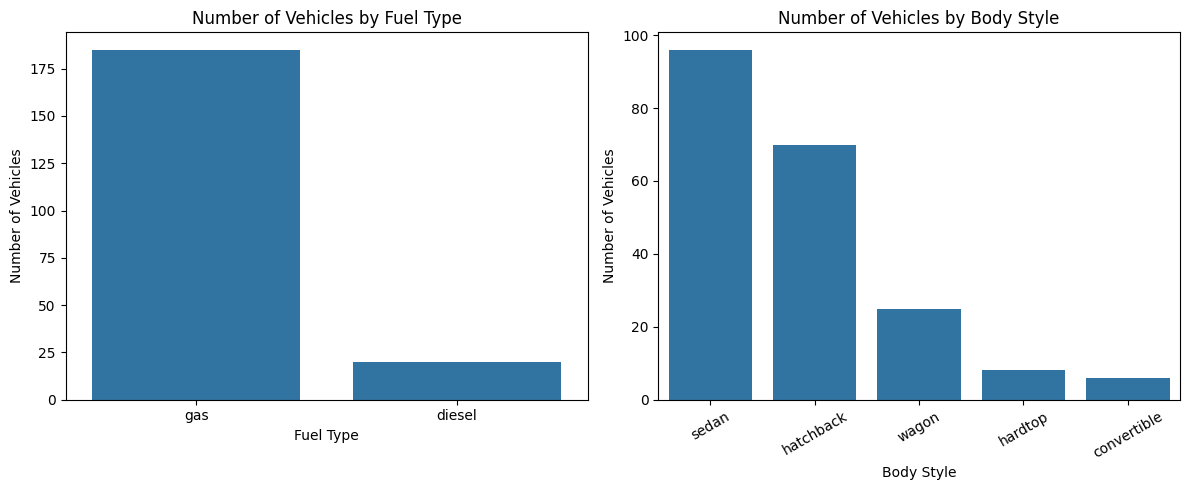

In [ ]:
# Create count plots for fuel type and body style
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="fueltype", ax=axes[0])
axes[0].set_title("Number of Vehicles by Fuel Type")
axes[0].set_xlabel("Fuel Type")
axes[0].set_ylabel("Number of Vehicles")

sns.countplot(
    data=df,
    x="carbody",
    order=df["carbody"].value_counts().index,
    ax=axes[1]
)
axes[1].set_title("Number of Vehicles by Body Style")
axes[1].set_xlabel("Body Style")
axes[1].set_ylabel("Number of Vehicles")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

---

> **Key Findings — Categorical Feature Visualisation**
>
> - **Fuel type:** Gas vehicles dominate the dataset, with 185 vehicles compared with only 20 diesel vehicles.
> - **Body style:** Sedans are the most common category (96 vehicles), followed by hatchbacks (70) and wagons (25).
> - **Less-represented categories:** Hardtops and convertibles have relatively few observations, with 8 and 6 vehicles respectively.
> - **Data imbalance:** The unequal representation of categories should be considered when comparing prices across groups and evaluating model performance.
>
> **Conclusion:** The charts show that the dataset is concentrated in gas-powered vehicles and sedan or hatchback body styles. These distributions provide useful context for the subsequent analysis of vehicle prices.

### Car Price by Drivetrain

This analysis examines how car prices vary across drivetrain categories: front-wheel drive (`fwd`), rear-wheel drive (`rwd`), and four-wheel drive (`4wd`).

Grouped descriptive statistics will be used to compare the number of vehicles, mean price, median price, and price variability within each category. A boxplot will then help visualise differences in price distributions and identify potential outliers.

The results will provide context for the subsequent hypothesis test comparing front-wheel-drive and rear-wheel-drive vehicles.

In [ ]:
# Summarise car prices by drivetrain category
drivewheel_price_summary = (
    df.groupby("drivewheel")["price"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

# Display the grouped statistics
display(drivewheel_price_summary)

,count,mean,median,std,min,max
drivewheel,,,,,,
4wd,9,11087.46,9233.0,3988.64,7603.0,17859.17
fwd,120,9239.31,8222.0,3317.93,5118.0,23875.00
rwd,76,19910.81,16912.5,9120.14,6785.0,45400.00


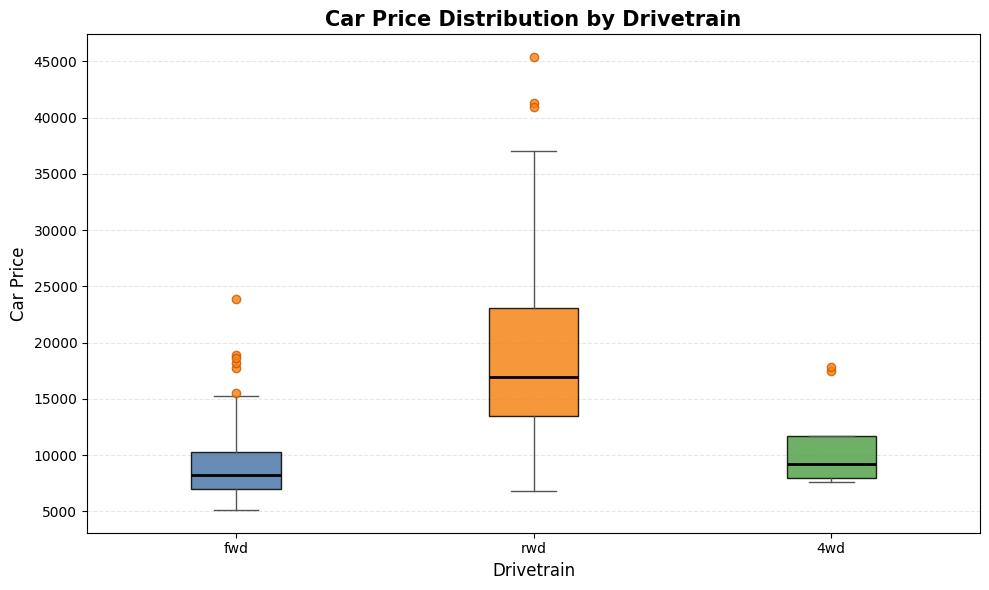

In [19]:
# Compare car prices across drivetrain categories
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare prices for each drivetrain
drivewheel_categories = ["fwd", "rwd", "4wd"]

price_data = [
    df.loc[df["drivewheel"] == category, "price"].dropna()
    for category in drivewheel_categories
]

# Create the boxplot
boxplot = ax.boxplot(
    price_data,
    labels=drivewheel_categories,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
    whiskerprops={"color": "#555555"},
    capprops={"color": "#555555"},
    flierprops={
        "marker": "o",
        "markerfacecolor": "#FF7F0E",
        "markeredgecolor": "#C45A00",
        "alpha": 0.8
    }
)

# Apply a different colour to each drivetrain
colors = ["#4C78A8", "#F58518", "#54A24B"]

for patch, color in zip(boxplot["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

# Add titles and labels
ax.set_title(
    "Car Price Distribution by Drivetrain",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Drivetrain", fontsize=12)
ax.set_ylabel("Car Price", fontsize=12)

# Add horizontal gridlines
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

---

> **Key Findings — Car Price by Drivetrain**
>
> - **Front-wheel drive (FWD):** The boxplot shows a relatively low median price and a narrower price distribution than RWD vehicles.
> - **Rear-wheel drive (RWD):** The median price is higher, and the distribution is wider, indicating greater variability in this group.
> - **Four-wheel drive (4WD):** The group contains only nine vehicles, so its observed price distribution should be interpreted cautiously.
> - **Potential outliers:** All three groups contain unusually high prices. These observations may represent genuine vehicles and should not be removed automatically.
>
> **Conclusion:** Car prices appear to vary across drivetrain categories in this dataset. A formal hypothesis test will be used to investigate whether the mean prices of FWD and RWD vehicles differ statistically.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is used to investigate the cleaned dataset, understand the distribution of car prices, identify relationships between vehicle characteristics and price, and explore patterns that may inform business decisions.

This section uses descriptive statistics and visualisations to address the project objective of understanding the factors associated with car prices. The findings will help guide subsequent statistical analysis, hypothesis testing, and machine learning model development.

### Distribution of Car Prices

Understanding the distribution of car prices helps identify typical price ranges, variability, and potential skewness in the dataset. This analysis uses a histogram to show the frequency of prices across different ranges and a box plot to summarise the distribution and highlight potential outliers.

These visualisations will help assess whether car prices are concentrated within a particular range or whether a small number of vehicles have substantially higher prices.

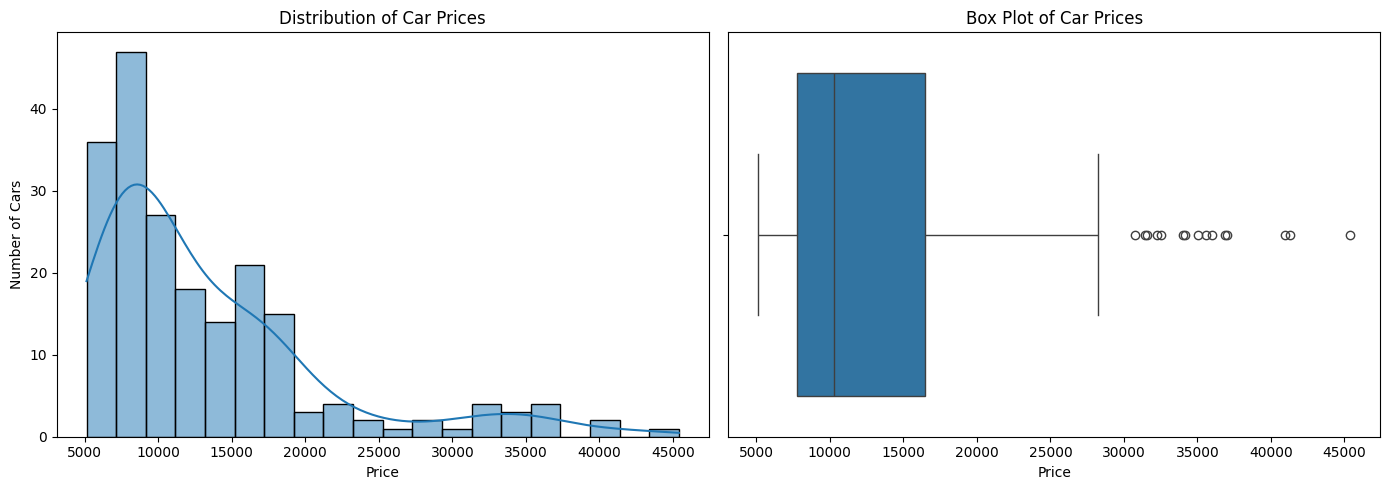

In [ ]:
# Create a figure with two plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: show the distribution of car prices
sns.histplot(data=df, x="price", bins=20, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Car Prices")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Number of Cars")

# Box plot: summarise price spread and potential outliers
sns.boxplot(data=df, x="price", ax=axes[1])
axes[1].set_title("Box Plot of Car Prices")
axes[1].set_xlabel("Price")

# Improve layout and display the plots
plt.tight_layout()
plt.show()

---

> **Key Findings — Distribution of Car Prices**
>
> - The histogram shows a **right-skewed distribution**: most cars are concentrated at lower price levels, while fewer cars have much higher prices.
> - The highest concentration of observations appears to be around the lower price ranges, particularly approximately 7,000–10,000.
> - The box plot shows a wide spread of prices and several potential high-price outliers above the upper whisker.
> - A small number of vehicles have prices above 30,000, with the maximum price appearing to be approximately 45,000.
>
> **Business implication:** The company should investigate which vehicle characteristics are associated with higher prices, as these may help explain differences in market positioning.
>
> **Note:** Potential outliers are not necessarily errors. They should be investigated alongside vehicle characteristics before any decision is made to remove or transform them.

### Average Car Price by Manufacturer

Comparing average car prices across manufacturers helps identify differences in price positioning within the dataset. A horizontal bar chart displays the average price for each manufacturer, making it easier to compare brands and identify those with higher or lower average prices.

This analysis supports the business objective of understanding pricing differences between manufacturers. However, average prices may also reflect differences in vehicle characteristics, such as engine size, horsepower, and vehicle weight. Therefore, the results will be interpreted as descriptive comparisons rather than evidence of causation.

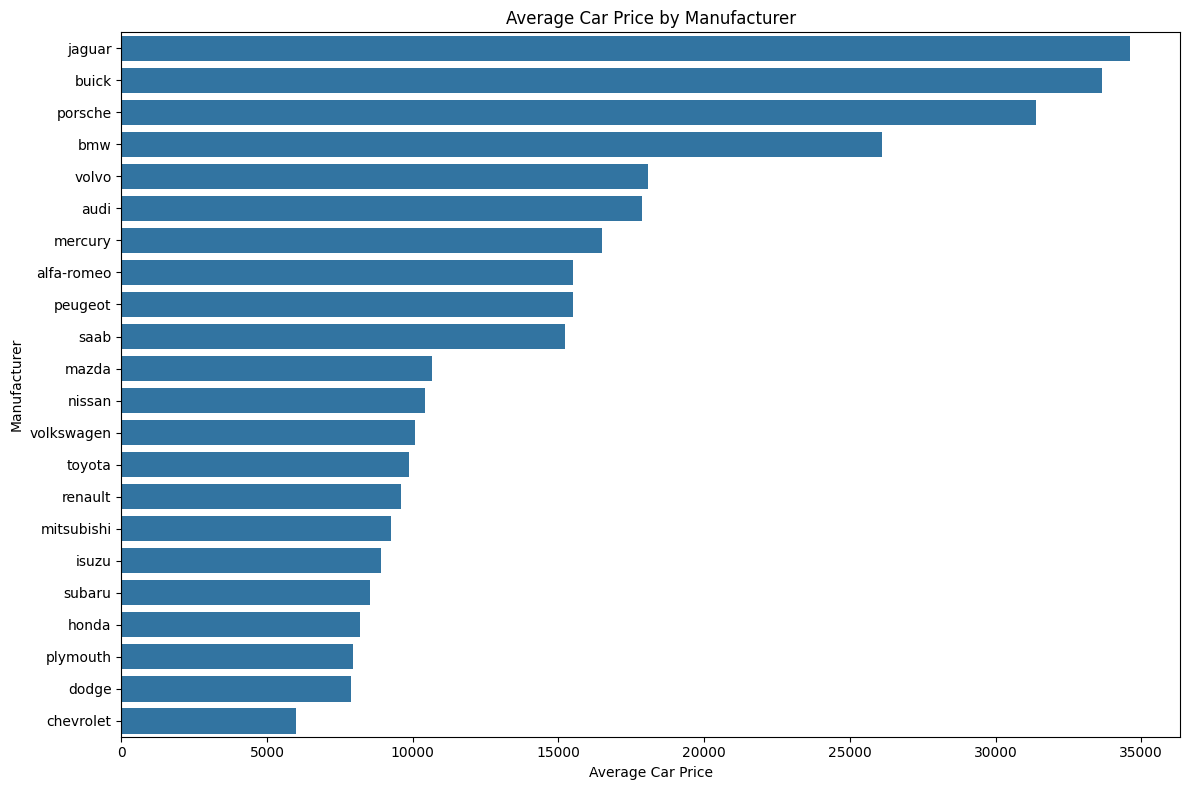

In [ ]:
# Calculate the average price for each manufacturer
avg_price_by_brand = (
    df.groupby("brand", as_index=False)["price"]
    .mean()
    .sort_values("price", ascending=False)
)

# Create a bar chart using Seaborn and Matplotlib
plt.figure(figsize=(12, 8))

sns.barplot(
    data=avg_price_by_brand,
    x="price",
    y="brand"
)

# Add titles and labels
plt.title("Average Car Price by Manufacturer")
plt.xlabel("Average Car Price")
plt.ylabel("Manufacturer")

# Format the chart
plt.tight_layout()
plt.show()

---

> **Key Findings — Average Car Price by Manufacturer**
>
> - **Highest average prices:** Jaguar has the highest average price at approximately 34,500, followed by Buick at around 33,700 and Porsche at around 31,400.
> - **Other high-priced manufacturers:** BMW has an average price of approximately 26,100, while Volvo and Audi are both around 18,000.
> - **Lowest average prices:** Chevrolet has the lowest average price at approximately 6,000, followed by Dodge and Plymouth at around 7,800.
> - **Differences between manufacturers:** The substantial variation in average prices suggests that the dataset contains vehicles positioned across different price segments.
>
> **Business implication:** These comparisons can help identify potential competitor groups and price segments. Further analysis of engine size, horsepower, vehicle weight and other characteristics is needed to understand these differences.
>
> **Limitation:** These are descriptive averages for the vehicles in this dataset. They do not establish that manufacturer identity causes a particular price.

### Relationship Between Engine Size and Car Price

Engine size is a vehicle characteristic that may be associated with its price. A scatter plot allows us to examine how car prices vary with engine size and identify possible patterns, clusters, and unusual observations.

This analysis supports the business objective of understanding which vehicle characteristics are associated with price differences. However, other factors, including horsepower, vehicle weight, and manufacturer, may also influence prices. The results will therefore be interpreted as associations rather than evidence of causation.

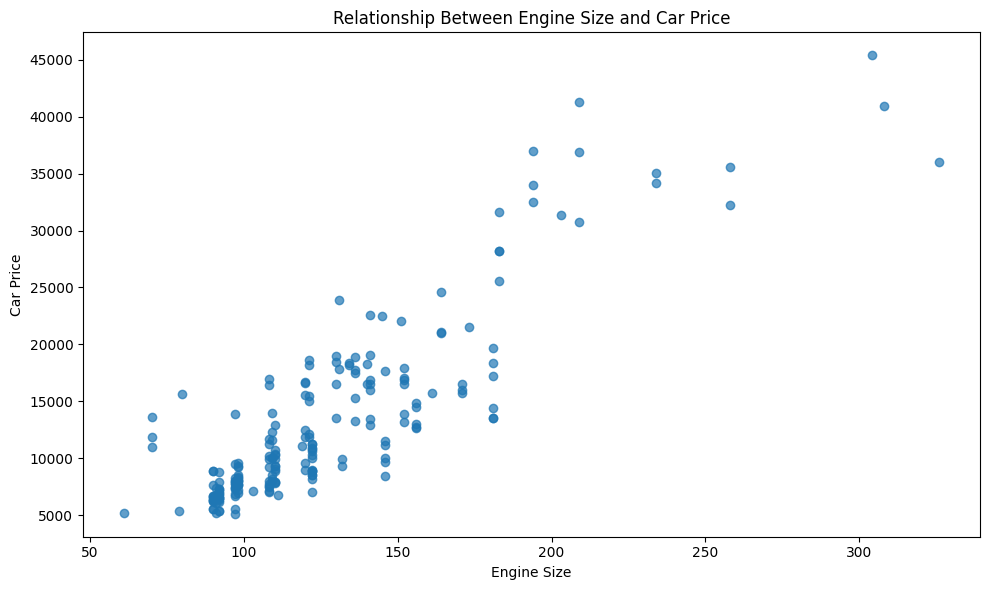

In [ ]:
# Create a scatter plot of engine size against car price
plt.figure(figsize=(10, 6))

plt.scatter(
    df["enginesize"],
    df["price"],
    alpha=0.7
)

# Add the chart title and axis labels
plt.title("Relationship Between Engine Size and Car Price")
plt.xlabel("Engine Size")
plt.ylabel("Car Price")

# Improve the chart layout
plt.tight_layout()
plt.show()

---

> **Key Findings — Relationship Between Engine Size and Car Price**
>
> - **Overall relationship:** The scatter plot shows [describe whether prices generally increase as engine size increases].
> - **Price variation:** Vehicles with similar engine sizes can have different prices, suggesting that other characteristics may also be important.
> - **Potential outliers:** [Describe any vehicles or observations that appear unusually expensive or inexpensive, if visible.]
>
> **Business implication:** Engine size may help explain differences in car prices and could be a useful feature in a price prediction model. Other variables, such as horsepower, vehicle weight, and manufacturer, should also be investigated.
>
> **Limitation:** The scatter plot shows an association between engine size and price; it does not demonstrate that engine size alone causes price differences.

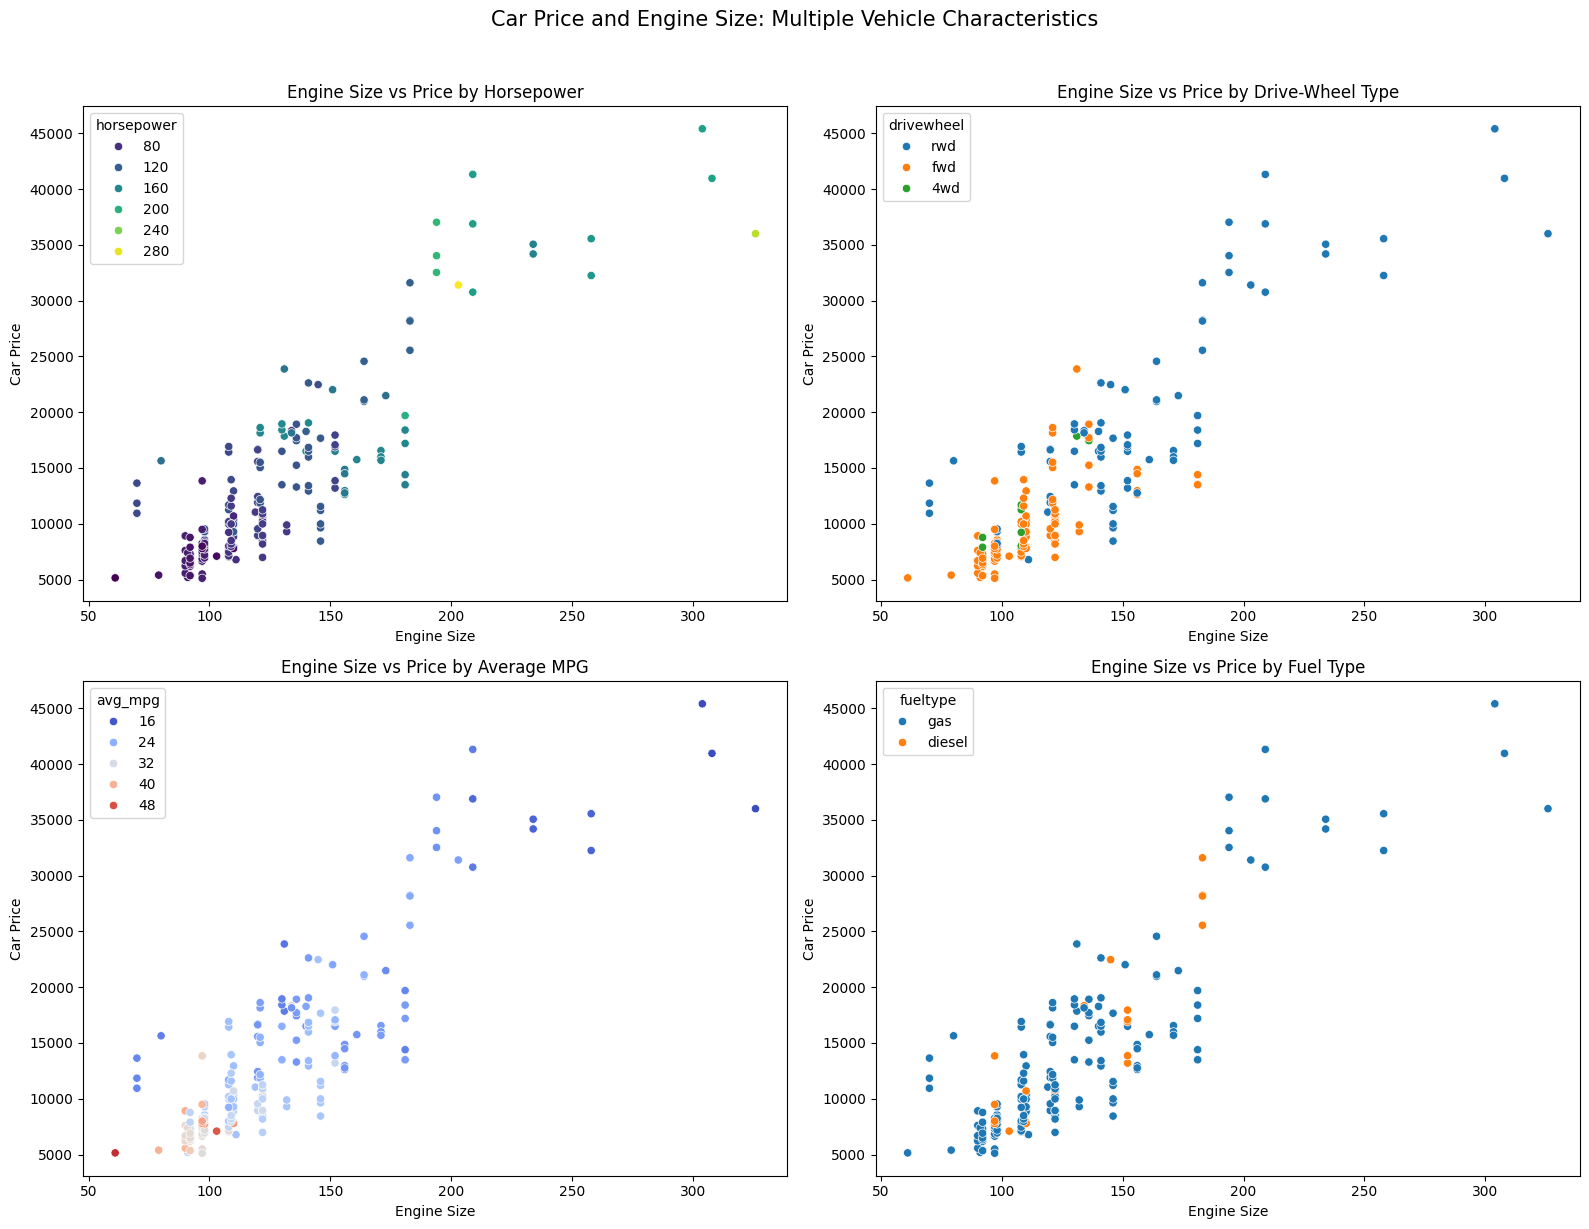

In [ ]:
# Create four scatter plots to explore car prices
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Colour by horsepower
sns.scatterplot(
    data=df,
    x="enginesize",
    y="price",
    hue="horsepower",
    palette="viridis",
    ax=axes[0, 0],
    legend="brief"
)
axes[0, 0].set_title("Engine Size vs Price by Horsepower")

# 2. Colour by drive-wheel type
sns.scatterplot(
    data=df,
    x="enginesize",
    y="price",
    hue="drivewheel",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Engine Size vs Price by Drive-Wheel Type")

# 3. Colour by average fuel economy
sns.scatterplot(
    data=df,
    x="enginesize",
    y="price",
    hue="avg_mpg",
    palette="coolwarm",
    ax=axes[1, 0],
    legend="brief"
)
axes[1, 0].set_title("Engine Size vs Price by Average MPG")

# 4. Colour by fuel type
sns.scatterplot(
    data=df,
    x="enginesize",
    y="price",
    hue="fueltype",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Engine Size vs Price by Fuel Type")

# Add axis labels to all four plots
for ax in axes.flat:
    ax.set_xlabel("Engine Size")
    ax.set_ylabel("Car Price")

# Add an overall title and prevent title overlap
fig.suptitle(
    "Car Price and Engine Size: Multiple Vehicle Characteristics",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

---

> **Key Findings — Engine Size, Car Price and Vehicle Characteristics**
>
> - **Engine size and price:** The plots show a positive association between engine size and car price. Vehicles with larger engines generally have higher prices, although there is variation between individual cars.
>
> - **Horsepower:** Higher-priced vehicles often have higher horsepower values. This suggests that horsepower may be a useful predictor of car price, although it may overlap with engine size.
>
> - **Drive-wheel type:** Rear-wheel-drive vehicles (`rwd`) appear among many of the higher-priced cars, while front-wheel-drive vehicles (`fwd`) are concentrated more heavily in the lower-to-middle price ranges. Four-wheel-drive vehicles (`4wd`) are relatively few in this dataset.
>
> - **Fuel economy:** Higher average MPG values are generally more common among vehicles with smaller engines and lower prices. This suggests a potential relationship between fuel economy, engine size and price.
>
> - **Fuel type:** Most observations are petrol (`gas`) vehicles, with fewer diesel vehicles. The limited number of diesel observations makes comparisons between fuel types less conclusive.
>
> **Business implication:** Engine size, horsepower, drive-wheel type and fuel economy are potential features for further investigation in the car price prediction model.
>
> **Limitation:** These plots show associations, not causation. The relationships should be examined alongside numerical summaries and model evaluation before drawing stronger conclusions.

### Correlation Analysis of Numerical Variables

Correlation analysis measures the strength and direction of linear relationships between numerical variables. A correlation heatmap presents these relationships visually, making it easier to identify variables associated with car price and potential relationships between predictor features.

This analysis will help identify candidate features for the car price prediction model and highlight possible multicollinearity between predictors. Correlation does not establish causation, and a weak linear correlation does not necessarily mean that two variables have no relationship.

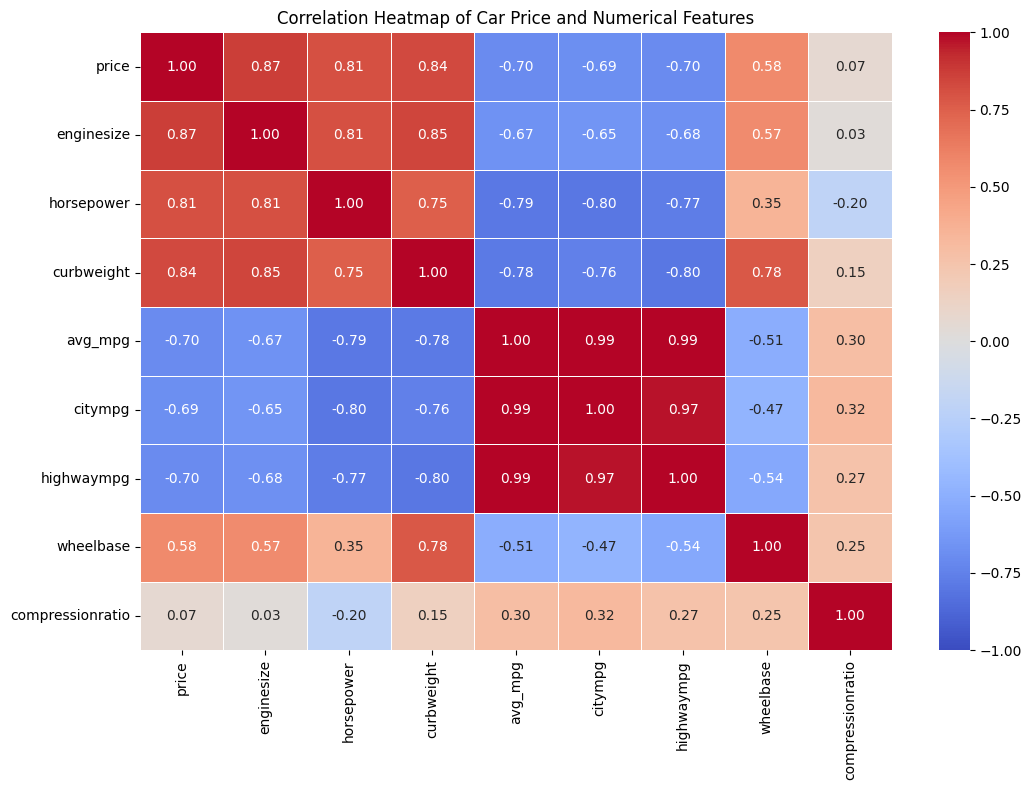

In [ ]:
# Select numerical variables relevant to car price analysis
correlation_columns = [
    "price",
    "enginesize",
    "horsepower",
    "curbweight",
    "avg_mpg",
    "citympg",
    "highwaympg",
    "wheelbase",
    "compressionratio"
]

# Calculate the correlation matrix
correlation_matrix = df[correlation_columns].corr()

# Create the correlation heatmap
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5
)

# Add the chart title
plt.title("Correlation Heatmap of Car Price and Numerical Features")
plt.tight_layout()
plt.show()

---

> **Key Findings — Correlation Analysis**
>
> - **Engine size and price:** Engine size has a strong positive correlation with price (**r = 0.87**). In this dataset, cars with larger engines tend to have higher prices.
>
> - **Horsepower and price:** Horsepower also has a strong positive correlation with price (**r = 0.81**), suggesting that engine power may be a useful feature for predicting car prices.
>
> - **Vehicle weight and price:** Curb weight has a strong positive correlation with price (**r = 0.84**). Heavier vehicles tend to be more expensive in this dataset.
>
> - **Fuel economy and price:** Average MPG has a negative correlation with price (**r = -0.70**). Vehicles with better fuel economy tend to have lower prices in this dataset, although other vehicle characteristics may contribute to this pattern.
>
> - **Relationships between predictors:** Engine size and curb weight are strongly correlated (**r = 0.85**), while average MPG is very strongly correlated with city MPG and highway MPG (**r = 0.99** for both). These relationships indicate overlapping information between some features.
>
> - **Compression ratio:** Its correlation with price is weak (**r = 0.07**), indicating little linear association with price in this dataset.
>
> **Business implication:** Engine size, horsepower and curb weight are promising candidate predictors for the price model. Their overlapping information should be considered during feature selection and model evaluation.
>
> **Limitation:** Correlation measures linear association, not causation. A weak correlation does not necessarily mean a feature has no predictive value, and the observed relationships may be influenced by other variables.

## Hypothesis Testing

Hypothesis testing uses statistical methods to assess whether an observed difference in a sample provides sufficient evidence of a difference between groups.

This section investigates whether mean car prices differ between front-wheel-drive (FWD) and rear-wheel-drive (RWD) vehicles in the dataset.

### Research Question

Is there a statistically significant difference in mean car prices between FWD and RWD vehicles?

### Hypotheses

- **Null hypothesis (H₀):** The population mean car prices for FWD and RWD vehicles are equal.
- **Alternative hypothesis (H₁):** The population mean car prices for FWD and RWD vehicles are different.

### Significance Level

The significance level is set at **α = 0.05**.

The analysis will examine group sizes and price distributions before selecting a suitable statistical test. A statistically significant result would indicate evidence of a difference in mean prices, but would not establish that drivetrain type causes the difference.

In [24]:
# Select front-wheel-drive and rear-wheel-drive vehicles
drive_groups = df[
    df["drivewheel"].isin(["fwd", "rwd"])
].copy()

# Calculate descriptive statistics for car prices in each group
drive_price_summary = (
    drive_groups.groupby("drivewheel")["price"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

# Display the results
display(drive_price_summary)

,count,mean,median,std,min,max
drivewheel,,,,,,
fwd,120,9239.31,8222.0,3317.93,5118.0,23875.0
rwd,76,19910.81,16912.5,9120.14,6785.0,45400.0


### Welch's Independent-Samples t-Test

Welch's independent-samples t-test is used to assess whether the population mean prices of two independent groups differ significantly. Unlike the standard Student's t-test, Welch's test does not assume equal population variances.

In this analysis, we compare the prices of front-wheel-drive (`fwd`) and rear-wheel-drive (`rwd`) vehicles.

- **Null hypothesis (H₀):** The population mean prices of FWD and RWD vehicles are equal.
- **Alternative hypothesis (H₁):** The population mean prices of FWD and RWD vehicles are different.
- **Significance level (α):** 0.05.

The p-value will be compared with the significance level to determine whether the null hypothesis should be rejected. The test assesses evidence of a difference in mean prices; it does not establish causation.

In [23]:
# Import the statistical test
from scipy.stats import ttest_ind

# Extract prices for each drivetrain group
fwd_prices = df.loc[df["drivewheel"] == "fwd", "price"]
rwd_prices = df.loc[df["drivewheel"] == "rwd", "price"]

# Perform Welch's independent-samples t-test
t_statistic, p_value = ttest_ind(
    fwd_prices,
    rwd_prices,
    equal_var=False,
    alternative="two-sided"
)

# Display the results
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.6f}")

# Compare the p-value with the significance level
alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print("Conclusion: There is evidence of a difference in mean prices.")
else:
    print("Decision: Fail to reject the null hypothesis.")
    print("Conclusion: There is insufficient evidence of a difference in mean prices.")

T-statistic: -9.7983
P-value: 0.000000
Decision: Reject the null hypothesis.
Conclusion: There is evidence of a difference in mean prices.


---

> **Key Findings — Welch's Independent-Samples t-Test**
>
> - **Test statistic:** The calculated t-statistic is -9.7983.
> - **P-value:** The p-value is below 0.05 and is displayed as 0.000000 when rounded to six decimal places.
> - **Decision:** Reject the null hypothesis.
> - **Interpretation:** There is statistically significant evidence that mean car prices differ between front-wheel-drive (FWD) and rear-wheel-drive (RWD) vehicles in this dataset.
> - **Direction of the difference:** The sample mean price for RWD vehicles (19,910.81) is higher than the sample mean for FWD vehicles (9,239.31).
>
> **Conclusion:** The results provide strong evidence of a difference in mean prices between the two drivetrain groups. This is an association in the observed dataset and does not establish that drivetrain type causes higher prices.

### Confidence Interval and Effect of the Difference

The p-value helps assess statistical significance, while a confidence interval estimates the plausible range for the difference between the population mean prices of RWD and FWD vehicles.

A 95% confidence interval will be calculated for the difference in mean prices (RWD minus FWD). If the interval does not include zero, this is consistent with a statistically significant difference at the 5% level for a two-sided test.

The exact p-value will also be displayed in scientific notation to avoid rounding a very small value to zero.

In [26]:
# Import the required functions
from scipy.stats import ttest_ind
from math import sqrt

# Perform Welch's t-test and retain the full result
test_result = ttest_ind(
    fwd_prices,
    rwd_prices,
    equal_var=False,
    alternative="two-sided"
)

# Calculate the difference in sample means (RWD minus FWD)
mean_difference = rwd_prices.mean() - fwd_prices.mean()

# Calculate the standard error for Welch's test
n_fwd = len(fwd_prices)
n_rwd = len(rwd_prices)

var_fwd = fwd_prices.var(ddof=1)
var_rwd = rwd_prices.var(ddof=1)

standard_error = sqrt(
    var_fwd / n_fwd + var_rwd / n_rwd
)

# Calculate Welch-Satterthwaite degrees of freedom
degrees_freedom = (
    (var_fwd / n_fwd + var_rwd / n_rwd) ** 2
    / (
        (var_fwd / n_fwd) ** 2 / (n_fwd - 1)
        + (var_rwd / n_rwd) ** 2 / (n_rwd - 1)
    )
)

# Calculate the 95% confidence interval
from scipy.stats import t

critical_value = t.ppf(0.975, degrees_freedom)

lower_bound = mean_difference - critical_value * standard_error
upper_bound = mean_difference + critical_value * standard_error

# Display the results
print(f"Mean price difference (RWD - FWD): {mean_difference:.2f}")
print(f"T-statistic: {test_result.statistic:.4f}")
print(f"Exact p-value: {test_result.pvalue:.6e}")
print(f"Degrees of freedom: {degrees_freedom:.2f}")
print(f"95% confidence interval: ({lower_bound:.2f}, {upper_bound:.2f})")

Mean price difference (RWD - FWD): 10671.50
T-statistic: -9.7983
Exact p-value: 9.634370e-16
Degrees of freedom: 87.71
95% confidence interval: (8507.01, 12835.99)


---

> **Key Findings — Welch's t-Test and Confidence Interval**
>
> - **Mean price difference:** RWD vehicles have a sample mean price 10,671.50 higher than FWD vehicles.
> - **Test statistic:** Welch's t-statistic is -9.7983, with approximately 87.71 degrees of freedom.
> - **P-value:** The exact p-value is approximately 9.63 × 10⁻¹⁶, which is substantially below the significance level of 0.05.
> - **Decision:** Reject the null hypothesis.
> - **95% confidence interval:** The estimated difference in population mean prices (RWD minus FWD) ranges from 8,507.01 to 12,835.99. The interval excludes zero.
>
> **Conclusion:** The results provide strong statistical evidence of a difference in mean prices between FWD and RWD vehicles. In this dataset, RWD vehicles have higher average prices. However, this observational comparison does not establish that drivetrain type causes higher prices; other characteristics, such as engine size, horsepower, and vehicle brand, may also contribute.

In [20]:
%matplotlib inline

---

# Section 2

Section 2 content

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)